Tutorial 2: Designing a Chromatin Loop (Dot) with AkitaSF
=============================================================================

This tutorial assumes you have completed Tutorial 1 (boundary design).
We will not repeat every concept explained there — if anything is unclear,
please refer back to Tutorial 1.

What is a dot?
--------------
In Hi-C contact maps, a "dot" (also called a loop anchor peak) is a focal
enrichment of contacts between two specific genomic loci — the two loop
anchors. It appears as a bright point off the diagonal of the contact map,
at the intersection of the row and column corresponding to the two anchors.
Dots are typically associated with convergent CTCF motifs and cohesin-
mediated loop extrusion.

How is the dot target defined?
------------------------------
Unlike the boundary tutorial, where the mask was defined analytically
(a rectangular off-diagonal block), the dot mask here is *data-driven*:
it is derived from a pileup of real Hi-C loops aggregated across many
loop calls. This pileup is a 15×15 patch of average contact enrichment
values centred on a loop, and it captures the realistic shape of a dot
feature — including the enrichment at the anchors and the slight
depletion of contacts in the surrounding neighbourhood.

The patch is stored in `data/data_driven_dot/data_driven_dot_mask.npy` and is loaded once.
A utility function places it onto the 512×512 contact map at the position
defined by the chosen inter-anchor distance, then converts the result into
the upper-triangular index/vector format that LocalL1Loss expects.

Key difference from Tutorial 1: two anchor bins
------------------------------------------------
For boundary design, Ledidi edited a single central bin (one anchor).
A dot requires editing *two* bins simultaneously — the two loop anchors —
because both must present compatible binding sites (typically a convergent
CTCF motif pair) to form a loop. We therefore use
`TwoAnchorSemifreddoLedidiWrapper`, which accepts a concatenated
`(1, 4, 2×BIN_SIZE)` tensor of both anchor bins and recomputes only the
relevant tower windows.

─────────────────────────────────────────────────────────────────────────────
Prerequisites
─────────────────────────────────────────────────────────────────────────────
Same environment as Tutorial 1. See `environment.yml` / `requirements.txt`.
Update the paths in the CONFIGURATION cell before running.

## Cell 1 — Imports

In [1]:
import os
import sys
import shutil

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from pyfaidx import Fasta

AKITA_PT_PATH  = "/path/to/akita_pytorch"
AKITA_SF_PATH  = "/path/to/akita_semifreddo"

sys.path.append(os.path.abspath(AKITA_PT_PATH))
sys.path.insert(0, os.path.abspath(AKITA_SF_PATH))

from akita.model import SeqNN
from ledidi import Ledidi
from semifreddo.semifreddo import TwoAnchorSemifreddoLedidiWrapper
from semifreddo.losses import LocalL1Loss
from utils.model_utils import store_tower_output, make_target
from utils.data_utils import (
    one_hot_encode_sequence,
    from_upper_triu,
)

# Import dot utils from the dot generation module.
sys.path.insert(0, os.path.abspath("../optimizations/dots/generation"))
from helper import place_pileup_at_center, dot_center_from_distance, make_dot_mask

print("All imports successful.")

All imports successful.


## Cell 2 — Configuration

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
MODEL_PATH  = "/path/to/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth"
FASTA_PATH  = "/path/to/mm10.fa"

PILEUP_PATH = "./../data/data_driven_dot/data_driven_dot_mask.npy"   # 15×15 pileup patch

# ── Genomic locus ─────────────────────────────────────────────────────────────
CHROM = "chr5"
START = 97957888
END   = 99268608
STEM  = f"{CHROM}_{START}_{END}"

TMP_DIR = "tmp_data"

# ── Architectural constants ───────────────────────────────────────────────────
MAP_SIZE       = 512
NUM_DIAGS      = 2
HALF           = MAP_SIZE // 2   # = 256
CENTER_BIN_MAP = 256
CROPPING       = 64
BIN_SIZE       = 2048
CONTEXT_BINS   = 5
N_TRIU         = 130305

# ── Dot design parameters ─────────────────────────────────────────────────────
# DISTANCE is the inter-anchor separation in bins. The two anchor bins are
# placed symmetrically around the centre of the 512-bin contact map:
#   anchor_lo = CENTER_BIN_MAP - DISTANCE // 2
#   anchor_hi = CENTER_BIN_MAP + DISTANCE // 2
# Increasing DISTANCE moves the dot further from the diagonal (larger loop).
DISTANCE      = 50
ANCHOR_OFFSET = DISTANCE // 2
BIN_ANCHOR_LO = CENTER_BIN_MAP - ANCHOR_OFFSET   # 256 - 25 = 231
BIN_ANCHOR_HI = CENTER_BIN_MAP + ANCHOR_OFFSET   # 256 + 25 = 281

# ── Optimisation hyperparameters ──────────────────────────────────────────────
L              = 150.0
MAX_ITER       = 2000
EARLY_STOPPING = 2000
# Note: on CPU, 2000 iterations can be slow. For a quick test, try MAX_ITER = 100
#       and EARLY_STOPPING = 100. Results will be partial but the pipeline will
#       run end-to-end in a few minutes.

# ── Visualisation ─────────────────────────────────────────────────────────────
VMIN, VMAX = -0.6, 0.6
CMAP       = "RdBu_r"

print("Configuration ready.")
print(f"  Anchor LO : bin {BIN_ANCHOR_LO}  (= centre − {ANCHOR_OFFSET})")
print(f"  Anchor HI : bin {BIN_ANCHOR_HI}  (= centre + {ANCHOR_OFFSET})")

Configuration ready.
  Anchor LO : bin 231  (= centre − 25)
  Anchor HI : bin 281  (= centre + 25)


Cell 3 — Dot mask utilities and building the mask
-----------------------------------------------------------------------------
The dot mask is built in three steps:

1. Load the 15×15 data-driven pileup patch from disk.
The patch encodes the average Hi-C contact enrichment (and surrounding
depletion) observed at real loop anchors.

2. Place the patch onto the 512×512 contact map at the position
`(BIN_ANCHOR_LO, BIN_ANCHOR_HI)`, mirrored across the diagonal.

3. Extract the upper-triangular indices and value vector — the same
format used by `LocalL1Loss` and make_target.

Pileup shape : (15, 15)  (expected: (15, 15))
Dot mask — non-zero entries : 225
Dot mask — index tensor     : (225,)


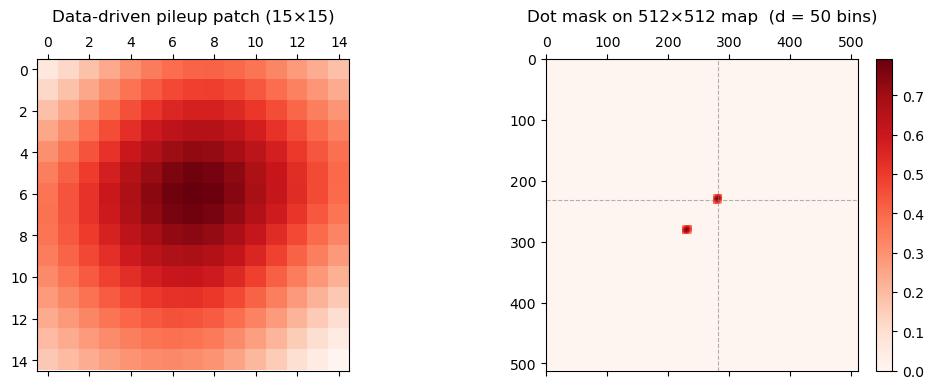

In [3]:
# ── Load pileup and build mask ────────────────────────────────────────────────
pileup = np.load(PILEUP_PATH)
print(f"Pileup shape : {pileup.shape}  (expected: (15, 15))")

dot_indices, dot_vector = make_dot_mask(pileup, DISTANCE)
print(f"Dot mask — non-zero entries : {(dot_vector != 0).sum().item():,}")
print(f"Dot mask — index tensor     : {tuple(dot_indices.shape)}")

# Preview the pileup patch and its placement in the full map
center    = dot_center_from_distance(DISTANCE)
full_mask = place_pileup_at_center(pileup, shape=(MAP_SIZE, MAP_SIZE), center=center)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].matshow(pileup, cmap="Reds")
axes[0].set_title("Data-driven pileup patch (15×15)", pad=10)
im = axes[1].matshow(full_mask, cmap="Reds")
axes[1].axhline(y=BIN_ANCHOR_LO, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
axes[1].axvline(x=BIN_ANCHOR_HI, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
axes[1].set_title(f"Dot mask on 512×512 map  (d = {DISTANCE} bins)", pad=10)
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Cell 4 — Pre-computing sequence, tower output, and dot target
-----------------------------------------------------------------------------
Identical workflow to Tutorial 1. The only difference is that we pass the
dot indices and vector to make_target instead of the boundary ones.

Device: cuda:0

Loading Akita v2 model …
Model loaded.

Sequence shape : (1, 4, 1310720)  → saved to tmp_data/chr5_97957888_99268608_X.pt
Tower shape    : (1, 128, 640)  → saved to tmp_data/chr5_97957888_99268608_tower_out.pt


/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


Target shape   : (1, 1, 130305)  → saved to tmp_data/chr5_97957888_99268608_dot_d50_target.pt


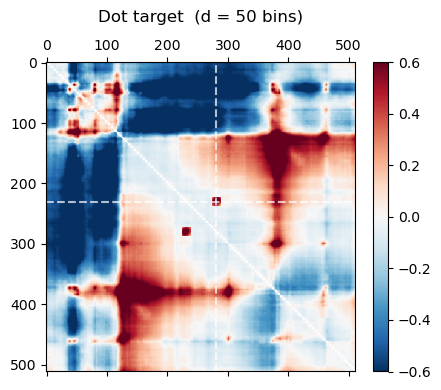

Dashed lines mark the two anchor bin positions.


In [4]:
os.makedirs(TMP_DIR, exist_ok=True)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

print("Loading Akita v2 model …")
model = SeqNN()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.to(device).eval()
print("Model loaded.\n")

# One-hot sequence
genome  = Fasta(FASTA_PATH)
seq_str = genome[CHROM][START:END]
X_np    = one_hot_encode_sequence(seq_str)
X       = torch.tensor(X_np)
if X.dim() == 2:
    X = X.unsqueeze(0)
X = X.to(device)
SEQ_PATH = os.path.join(TMP_DIR, f"{STEM}_X.pt")
torch.save(X.cpu(), SEQ_PATH)
print(f"Sequence shape : {tuple(X.shape)}  → saved to {SEQ_PATH}")

# Cached tower activations
TOWER_PATH = os.path.join(TMP_DIR, f"{STEM}_tower_out.pt")
store_tower_output(X, model, TOWER_PATH)
tower = torch.load(TOWER_PATH, weights_only=True).to(device)
print(f"Tower shape    : {tuple(tower.shape)}  → saved to {TOWER_PATH}")

# Dot target
target = make_target(model, X, dot_indices.to(device), dot_vector.to(device), device)
target = target.to(device)
TARGET_PATH = os.path.join(TMP_DIR, f"{STEM}_dot_d{DISTANCE}_target.pt")
torch.save(target, TARGET_PATH)
print(f"Target shape   : {tuple(target.shape)}  → saved to {TARGET_PATH}")

# Preview
mat_target = from_upper_triu(target[0, 0, :].cpu().numpy(), matrix_len=MAP_SIZE, num_diags=NUM_DIAGS)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.matshow(mat_target, cmap=CMAP, vmin=VMIN, vmax=VMAX)
ax.axhline(y=BIN_ANCHOR_LO, color="white", linestyle="--", linewidth=1.5, alpha=0.7)
ax.axvline(x=BIN_ANCHOR_HI, color="white", linestyle="--", linewidth=1.5, alpha=0.7)
ax.set_title(f"Dot target  (d = {DISTANCE} bins)", pad=12)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
print("Dashed lines mark the two anchor bin positions.")

Cell 5 — `TwoAnchorSemifreddoLedidiWrapper` and sanity check
 -----------------------------------------------------------------------------
Dots require editing two bins simultaneously — one at each loop anchor.
TwoAnchorSemifreddoLedidiWrapper handles this by maintaining two cached
tower windows (one centred on `BIN_ANCHOR_LO`, one on `BIN_ANCHOR_HI`) and
recomputing only those windows during each Ledidi forward pass.

The input to Ledidi is a concatenated tensor of both anchor bins:    
`X_anchors = cat([X_lo, X_hi]`, dim=2,   shape: `(1, 4, 2 × BIN_SIZE)`    
After optimisation, the two halves are split and written back into the
full sequence independently.

In [5]:
sf_wrapper = TwoAnchorSemifreddoLedidiWrapper(
    model                   = model,
    precomputed_full_output = tower,
    full_X                  = X,
    bin_lo                  = BIN_ANCHOR_LO,
    bin_hi                  = BIN_ANCHOR_HI,
    context_bins            = CONTEXT_BINS,
    cropping_applied        = CROPPING,
)

bp_lo_start = sf_wrapper.bp_lo_start
bp_lo_end   = sf_wrapper.bp_lo_end
bp_hi_start = sf_wrapper.bp_hi_start
bp_hi_end   = sf_wrapper.bp_hi_end

X_lo      = X[:, :, bp_lo_start:bp_lo_end]
X_hi      = X[:, :, bp_hi_start:bp_hi_end]
X_anchors = torch.cat([X_lo, X_hi], dim=2)   # (1, 4, 2 × BIN_SIZE)

print(f"Anchor LO : bin {BIN_ANCHOR_LO} — bp {bp_lo_start:,}–{bp_lo_end:,}")
print(f"Anchor HI : bin {BIN_ANCHOR_HI} — bp {bp_hi_start:,}–{bp_hi_end:,}")
print(f"X_anchors shape : {tuple(X_anchors.shape)}")

with torch.no_grad():
    y_full = model(X)
    y_sf   = sf_wrapper(X_anchors)

r, _ = pearsonr(y_full.cpu().flatten().numpy(), y_sf.cpu().flatten().numpy())
print(f"\nSanity check — Pearson R (full vs two-anchor Semifreddo): {r:.6f}  (expect ≈ 1.0)")

Anchor LO : bin 231 — bp 604,160–606,208
Anchor HI : bin 281 — bp 706,560–708,608
X_anchors shape : (1, 4, 4096)

Sanity check — Pearson R (full vs two-anchor Semifreddo): 1.000000  (expect ≈ 1.0)


## Cell 6 — Loss function and optimisation

In [6]:
local_output_loss = LocalL1Loss(
    dot_indices.to(device), n_triu=N_TRIU, reduction="sum"
).to(device)

ledidi_optimizer = Ledidi(
    sf_wrapper,
    shape               = X_anchors.shape[1:],   # (4, 2 × BIN_SIZE)
    input_loss          = torch.nn.L1Loss(reduction="sum"),
    output_loss         = local_output_loss,
    batch_size          = 1,
    l                   = L,
    max_iter            = MAX_ITER,
    early_stopping_iter = EARLY_STOPPING,
    return_history      = True,
    verbose             = True,
).cuda() # remove .cuda() if on CPU

print("Running optimisation … (this may take a few minutes)\n")
generated_anchors, history = ledidi_optimizer.fit_transform(X_anchors, target)
print("\nOptimisation complete.")

Running optimisation … (this may take a few minutes)

iter=I	input_loss=0.0	output_loss=7.312e+04	total_loss=7.312e+04	time=0.0
iter=100	input_loss=16.0	output_loss=7.283e+04	total_loss=7.523e+04	time=7.576
iter=200	input_loss=341.0	output_loss=3.888e+04	total_loss=9.003e+04	time=7.489
iter=300	input_loss=285.0	output_loss=1.725e+04	total_loss=6e+04	time=7.493
iter=400	input_loss=139.0	output_loss=1.685e+04	total_loss=3.77e+04	time=7.495
iter=500	input_loss=96.0	output_loss=1.681e+04	total_loss=3.121e+04	time=7.496
iter=600	input_loss=94.0	output_loss=1.697e+04	total_loss=3.107e+04	time=7.495
iter=700	input_loss=97.0	output_loss=1.605e+04	total_loss=3.06e+04	time=7.495
iter=800	input_loss=97.0	output_loss=1.708e+04	total_loss=3.163e+04	time=7.497
iter=900	input_loss=218.0	output_loss=1.704e+04	total_loss=4.974e+04	time=7.499
iter=1000	input_loss=110.0	output_loss=1.709e+04	total_loss=3.359e+04	time=7.502
iter=1100	input_loss=89.0	output_loss=1.615e+04	total_loss=2.95e+04	time=7.501
ite

## Cell 7 — Reconstructing the full sequence and plotting loss curves

Edited nucleotides: 59 / 4,096 across both anchor bins


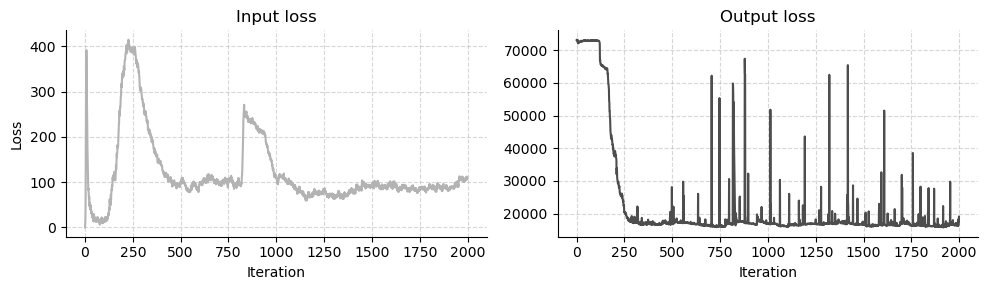

In [7]:
# Split the two optimised anchor bins and splice back into the full sequence
full_generated_seq = X.clone()
full_generated_seq[:, :, bp_lo_start:bp_lo_end] = generated_anchors[:, :, :BIN_SIZE]
full_generated_seq[:, :, bp_hi_start:bp_hi_end] = generated_anchors[:, :, BIN_SIZE:]

n_edits = (
    torch.argmax(full_generated_seq, dim=1) != torch.argmax(X, dim=1)
).sum().item()
print(f"Edited nucleotides: {n_edits:,} / {2 * BIN_SIZE:,} across both anchor bins")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(history["input_loss"],  c="0.7")
axes[0].set_title("Input loss")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(history["output_loss"], c="0.3")
axes[1].set_title("Output loss")
axes[1].set_xlabel("Iteration")
axes[1].grid(True, linestyle="--", alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()

## Cell 8 — Evaluation: Pearson R and contact map visualisation

Pearson R (optimised vs target) : 0.8314
Pearson R (initial   vs target) : 0.9979


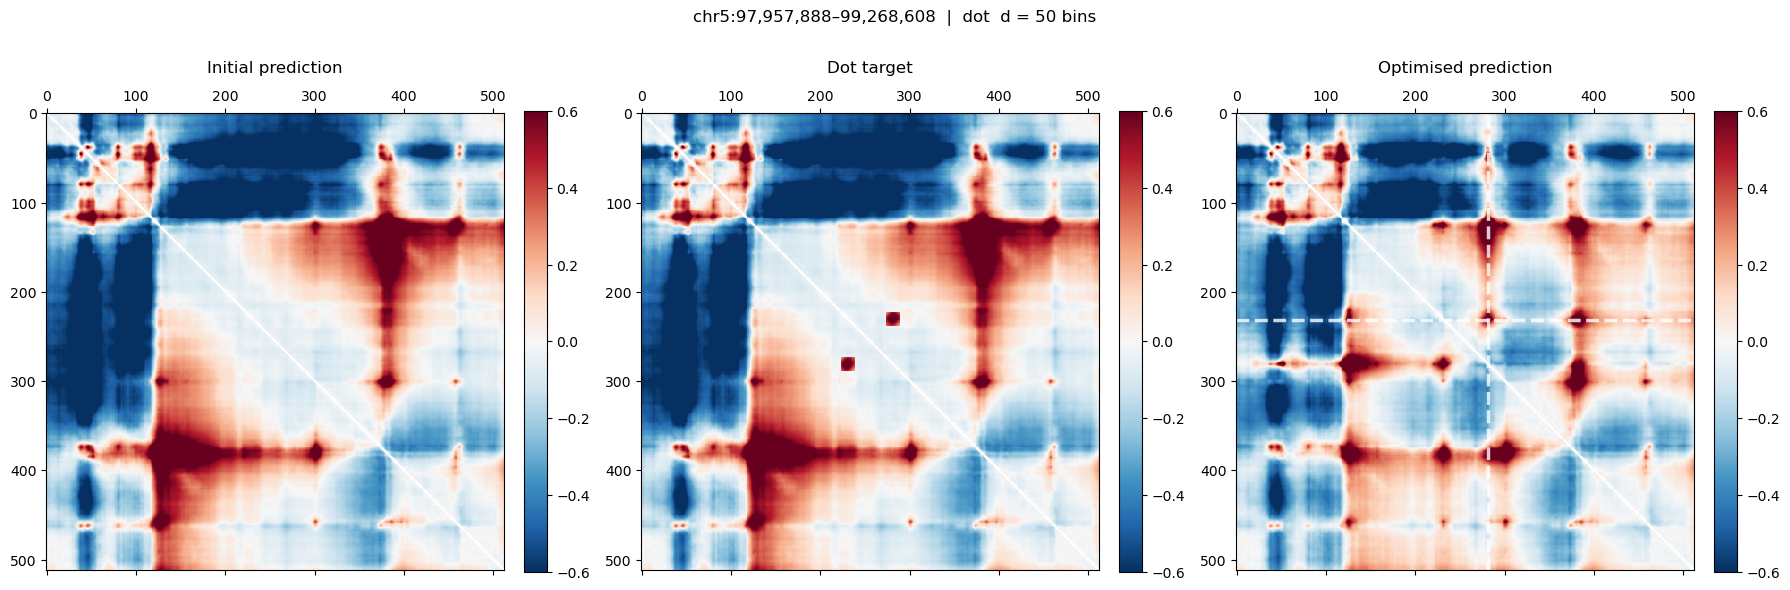

The dashed lines on the optimised map mark the two anchor bins.
A successful design shows focal contact enrichment at their intersection.
As always, inspect the map critically — verify that the dot is focal
and that the surrounding contact structure looks plausible.


In [8]:
model.eval()
with torch.no_grad():
    pred_initial   = model(X)
    pred_optimised = model(full_generated_seq)

r_opt,  _ = pearsonr(pred_optimised.cpu().flatten().numpy(), target.cpu().flatten().numpy())
r_init, _ = pearsonr(pred_initial.cpu().flatten().numpy(),   target.cpu().flatten().numpy())
print(f"Pearson R (optimised vs target) : {r_opt:.4f}")
print(f"Pearson R (initial   vs target) : {r_init:.4f}")

mat_initial   = from_upper_triu(pred_initial[0, 0, :].cpu().numpy(),   matrix_len=MAP_SIZE, num_diags=NUM_DIAGS)
mat_optimised = from_upper_triu(pred_optimised[0, 0, :].cpu().numpy(), matrix_len=MAP_SIZE, num_diags=NUM_DIAGS)
mat_target    = from_upper_triu(target[0, 0, :].cpu().numpy(),         matrix_len=MAP_SIZE, num_diags=NUM_DIAGS)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, mat, title in zip(
    axes,
    [mat_initial, mat_target, mat_optimised],
    ["Initial prediction", "Dot target", "Optimised prediction"],
):
    im = ax.matshow(mat.astype(np.float32), cmap=CMAP, vmin=VMIN, vmax=VMAX)
    ax.set_title(title, pad=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Mark anchor positions on the optimised map
axes[2].axhline(y=BIN_ANCHOR_LO, color="white", linestyle="--", linewidth=2.5, alpha=0.8)
axes[2].axvline(x=BIN_ANCHOR_HI, color="white", linestyle="--", linewidth=2.5, alpha=0.8)

plt.suptitle(
    f"{CHROM}:{START:,}–{END:,}  |  dot  d = {DISTANCE} bins",
    y=1.02,
)
plt.tight_layout()
plt.show()

print("The dashed lines on the optimised map mark the two anchor bins.")
print("A successful design shows focal contact enrichment at their intersection.")
print("As always, inspect the map critically — verify that the dot is focal")
print("and that the surrounding contact structure looks plausible.")

## Cell 9 — Cleanup

In [9]:
shutil.rmtree(TMP_DIR)
print(f"Removed {TMP_DIR}/")
print()
print("─" * 70)
print("Tutorial 2 complete!")
print()
print("Key differences from Tutorial 1 (boundary):")
print("  • The target is data-driven: a real Hi-C loop pileup patch,")
print("    not an analytically defined rectangle.")
print("  • Two anchor bins are optimised simultaneously via")
print("    TwoAnchorSemifreddoLedidiWrapper — one bin per loop anchor.")
print("  • The inter-anchor distance (DISTANCE) controls where the dot")
print("    appears in the contact map; try values between 20 and 100 bins.")
print("─" * 70)

Removed tmp_data/

──────────────────────────────────────────────────────────────────────
Tutorial 2 complete!

Key differences from Tutorial 1 (boundary):
  • The target is data-driven: a real Hi-C loop pileup patch,
    not an analytically defined rectangle.
  • Two anchor bins are optimised simultaneously via
    TwoAnchorSemifreddoLedidiWrapper — one bin per loop anchor.
  • The inter-anchor distance (DISTANCE) controls where the dot
    appears in the contact map; try values between 20 and 100 bins.
──────────────────────────────────────────────────────────────────────
